# Imports

In [1]:
from torch.utils.data import DataLoader, random_split
import torch
from data import PermutationDataset
from model import PermutationModel
from train import train_one_epoch, evaluate_model
import matplotlib.pyplot as plt

# Parameters
This includes parameters for what to train on and predict, and also the hyperparameters for training.

In [2]:
n = 5
label_name = "stat1"
layers = [2]

epochs = 1000
train_split, test_split = 0.8, 0.2
learning_rate = 0.001
momentum = 0.9
batch_size = 64

# Initialization
Initialize the data loaders, model, loss function, optimizers.

In [3]:
full_dataset = PermutationDataset(n, label_name)
training_dataset, test_dataset = random_split(full_dataset, [train_split, test_split])
model = PermutationModel(n, layers)
loss_fn = torch.nn.CrossEntropyLoss(full_dataset.class_weights())
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, momentum=momentum)
training_loader = DataLoader(training_dataset, batch_size=batch_size, shuffle=True)
losses = []

# Training loop
Train the model for the appropriate number of epochs and then save the model in `models`.

In [4]:
for epoch in range(epochs):
    model.train(True)
    current_loss = train_one_epoch(training_loader, model, loss_fn, optimizer)
    print(f"Epoch {epoch}, Loss {current_loss}")
    losses.append(current_loss)

torch.save(model.state_dict(), f"models/{label_name}_{n}.pt")

Epoch 0, Loss 1.6503368616104126
Epoch 1, Loss 1.6186287999153137
Epoch 2, Loss 1.6138265132904053
Epoch 3, Loss 1.6180390119552612
Epoch 4, Loss 1.5489779114723206
Epoch 5, Loss 1.5047058463096619
Epoch 6, Loss 1.6086516380310059
Epoch 7, Loss 1.6027738451957703
Epoch 8, Loss 1.5840147733688354
Epoch 9, Loss 1.585005283355713
Epoch 10, Loss 1.4924278259277344
Epoch 11, Loss 1.5618426203727722
Epoch 12, Loss 1.5124255418777466
Epoch 13, Loss 1.49919992685318
Epoch 14, Loss 1.531998097896576
Epoch 15, Loss 1.5110268592834473
Epoch 16, Loss 1.497596263885498
Epoch 17, Loss 1.4369216561317444
Epoch 18, Loss 1.4618840217590332
Epoch 19, Loss 1.451923906803131
Epoch 20, Loss 1.4494202136993408
Epoch 21, Loss 1.4339531064033508
Epoch 22, Loss 1.461941659450531
Epoch 23, Loss 1.4069091081619263
Epoch 24, Loss 1.4338566660881042
Epoch 25, Loss 1.4150519371032715
Epoch 26, Loss 1.38204026222229
Epoch 27, Loss 1.413901686668396
Epoch 28, Loss 1.4167607426643372
Epoch 29, Loss 1.4032343626022339


# Print the loss curve
Visualize the loss curve to ensure that the model is learning correctly. Save the loss curve in `figures/` so that you can refer to them later.

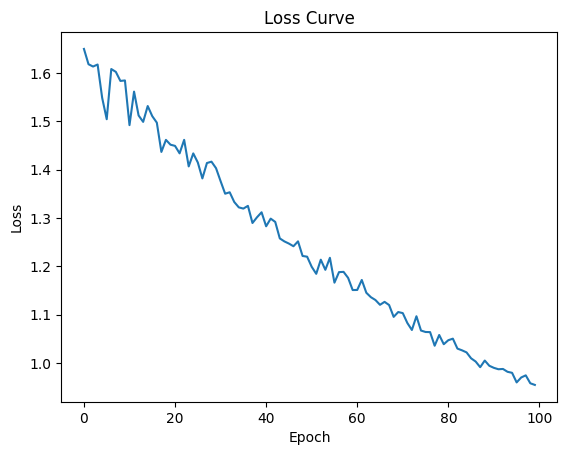

In [5]:
# TODO
# Create a figure and axis
fig, ax = plt.subplots()

# Plot the loss curve
ax.plot(range(len(losses)), losses)

# Add labels and title
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Loss Curve')

# Show the plot
plt.show()

# Evaluate the model
Compute the confusion matrix on the train and test dataset and print out the accuracy and plot the confusion matrix.

In [6]:
# TODO
confusion_matrix = evaluate_model(model, test_dataset)
confusion_matrix.print_accuracy()

Accuracy for class 0 = 84.21052631578948%
Accuracy for class 1 = 100.0%
Overall accuracy = 87.5%


# Plot model weights and connections.
Plot the model weights and connections in order to attempt to interpret what the model is learning.

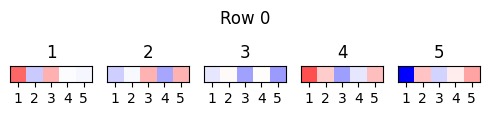

In [7]:
model.plot_heatmap_feature(0,0)